# Bankruptcy & Fraud Risk Predictor
**Course:** BA870-AC820  
**Data:** SEC EDGAR 10-K Filings (2000–2024) + Yahoo Finance  

---

## Project Overview

This notebook walks through the full end-to-end pipeline for predicting corporate bankruptcy and fraud risk using publicly available financial data.

### The question we're answering:
> *Can we predict which public companies are likely to go bankrupt, using only their financial statement ratios?*

### Our approach:
1. **Data Collection** — Pull 10-K annual filing data from SEC EDGAR for 30 companies (15 bankrupt, 15 healthy)
2. **Feature Engineering** — Compute key financial ratios and the classic Altman Z-Score
3. **Model Training** — Train a logistic regression classifier and compare it to two rule-based benchmarks
4. **Results** — Evaluate all models with ROC curves, confusion matrices, and feature importance charts

---

## Setup — Imports & Configuration

In [1]:
# Standard library
import pickle
import warnings
warnings.filterwarnings('ignore')

# Data
import numpy as np
import pandas as pd
pd.set_option('display.max_columns', 20)
pd.set_option('display.width', 120)
pd.set_option('display.float_format', '{:.3f}'.format)

# Visualisation (matplotlib renders as static images on GitHub)
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
%matplotlib inline
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

# Machine learning
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.metrics import (
    accuracy_score, roc_auc_score, roc_curve, auc,
    confusion_matrix, classification_report
)

# Project utilities
import sys, os
sys.path.insert(0, os.path.abspath('.'))
from utils.companies import COMPANIES
from utils.altman_zscore import add_zscores
from utils.fraud_score import add_fraud_scores

print('All imports successful ✓')

All imports successful ✓


---
## Phase 1 — Data Collection

### 1.1 Company Universe

We built a curated list of 30 companies — a balanced mix of well-known bankruptcies and healthy large-cap firms. Each company has a confirmed SEC EDGAR CIK (Central Index Key), which is how EDGAR identifies filers.

**Why these companies?**  
- Bankrupt companies: chosen because their outcomes are verifiable and their EDGAR filings are complete
- Healthy companies: large, well-known firms with strong financials to provide a clear contrast
- Balanced dataset: 15 bankrupt vs. 15 healthy prevents the model from cheating by always predicting "healthy"

In [2]:
# Load company list from our utils module
companies_df = pd.DataFrame(COMPANIES)

print(f'Total companies: {len(companies_df)}')
print(f'Bankrupt:        {companies_df["bankrupt"].sum()}')
print(f'Healthy:         {(companies_df["bankrupt"]==0).sum()}')
print(f'Sectors covered: {companies_df["sector"].nunique()}')
print()

companies_df[['ticker','name','sector','bankrupt','year_filed']]

Total companies: 30
Bankrupt:        15
Healthy:         15
Sectors covered: 8



,ticker,name,sector,bankrupt,year_filed
0,ENRNQ,Enron Corp,Energy,1,2001.000
1,LEHMQ,Lehman Brothers,Financials,1,2008.000
2,GM,General Motors (old),Consumer Discretionary,1,2009.000
3,SHLDQ,Sears Holdings,Consumer Discretionary,1,2018.000
4,RSHCQ,RadioShack,Consumer Discretionary,1,2015.000
5,CCTYQ,Circuit City,Consumer Discretionary,1,2008.000
6,BLOKQ,Blockbuster,Consumer Discretionary,1,2010.000
7,KMART,Kmart,Consumer Staples,1,2002.000
8,WCOM,WorldCom / MCI,Telecom,1,2002.000
9,WAMUQ,Washington Mutual,Financials,1,2008.000


### 1.2 SEC EDGAR Data

For each company we queried the **SEC EDGAR XBRL API** at:  
`https://data.sec.gov/api/xbrl/companyfacts/{CIK}.json`

This free API returns every line-item a company ever reported in a 10-K filing — total assets, liabilities, revenue, etc. — in structured JSON going back to the early 2000s.

We extracted the **most recent annual (10-K) value** for each of these XBRL concepts:

| Our Name | XBRL Concept | What it means |
|---|---|---|
| `total_assets` | `Assets` | Everything the company owns |
| `total_liabilities` | `Liabilities` | Everything the company owes |
| `current_assets` | `AssetsCurrent` | Assets convertible to cash within 1 year |
| `current_liabilities` | `LiabilitiesCurrent` | Debts due within 1 year |
| `retained_earnings` | `RetainedEarningsAccumulatedDeficit` | Profits kept over company lifetime |
| `revenue` | `Revenues` | Total sales |
| `net_income` | `NetIncomeLoss` | Profit after all expenses |
| `ebit` | `OperatingIncomeLoss` | Profit before interest & taxes |
| `interest_expense` | `InterestExpense` | Cost of servicing debt |
| `stockholders_equity` | `StockholdersEquity` | Net worth (Assets − Liabilities) |

In [3]:
# Load the raw financials CSV collected in Phase 1
raw = pd.read_csv('data/processed/financials.csv')

print(f'Raw dataset: {len(raw)} companies × {len(raw.columns)} columns')
print(f'Missing values per key column:')
key_cols = ['total_assets','revenue','net_income','current_ratio','debt_to_equity']
print(raw[key_cols].isnull().sum().to_string())
print()

# Show the raw financial numbers (in USD billions for readability)
display_raw = raw[['ticker','name','bankrupt','total_assets','revenue','net_income',
                    'current_ratio','debt_to_equity','return_on_assets']].copy()
display_raw['total_assets'] = (display_raw['total_assets'] / 1e9).round(1)
display_raw['revenue']      = (display_raw['revenue'] / 1e9).round(1)
display_raw['net_income']   = (display_raw['net_income'] / 1e9).round(1)
display_raw = display_raw.rename(columns={
    'total_assets': 'Assets ($B)', 'revenue': 'Revenue ($B)', 'net_income': 'Net Income ($B)'
})
display_raw

Raw dataset: 30 companies × 30 columns
Missing values per key column:
total_assets       3
revenue           12
net_income         4
current_ratio      7
debt_to_equity    16



,ticker,name,bankrupt,Assets ($B),Revenue ($B),Net Income ($B),current_ratio,debt_to_equity,return_on_assets
0,ENRNQ,Enron Corp,1,19.600,6.700,1.600,0.400,0.747,0.079
1,LEHMQ,Lehman Brothers,1,0.000,0.000,-0.000,1.821,0.621,-0.224
2,GM,General Motors (old),1,0.400,NaN,NaN,NaN,NaN,NaN
3,SHLDQ,Sears Holdings,1,7.300,NaN,-0.400,0.776,-2.951,-0.053
4,RSHCQ,RadioShack,1,1.600,NaN,-0.400,2.280,6.709,-0.252
5,CCTYQ,Circuit City,1,199.200,NaN,26.800,1.028,NaN,0.135
6,BLOKQ,Blockbuster,1,NaN,NaN,NaN,NaN,NaN,NaN
7,KMART,Kmart,1,15.600,12.700,1.300,0.806,NaN,0.086
8,WCOM,WorldCom / MCI,1,NaN,NaN,NaN,NaN,NaN,NaN
9,WAMUQ,Washington Mutual,1,18.900,2.200,0.900,NaN,3.482,0.049


---
## Phase 2 — Feature Engineering

Raw financial statement numbers are hard to compare across companies of different sizes. A company with \$1B in debt means something very different if it has \$500M in assets vs. \$50B. 

**Ratios solve this** by normalising numbers relative to company size.

### 2.1 The Four Key Ratios

| Ratio | Formula | What it measures | Red flag if... |
|---|---|---|---|
| **Current Ratio** | Current Assets / Current Liabilities | Can the company pay short-term bills? | < 1.0 |
| **Debt / Equity** | Total Liabilities / Stockholders Equity | How leveraged is the company? | > 3.0 |
| **Return on Assets** | Net Income / Total Assets | How profitably are assets used? | Negative |
| **Interest Coverage** | EBIT / Interest Expense | Can the company afford its debt interest? | < 1.5× |

In [4]:
# Load the cleaned feature matrix from Phase 2
features = pd.read_csv('data/processed/features.csv')

print(f'Feature matrix: {len(features)} companies × {len(features.columns)} columns')
print(f'  Bankrupt: {features["bankrupt"].sum()},  Healthy: {(features["bankrupt"]==0).sum()}')
print()

# Show key ratios side by side — bankrupt vs healthy averages
ratio_cols = ['current_ratio','debt_to_equity','return_on_assets',
              'net_margin','interest_coverage']
comparison = features.groupby('bankrupt')[ratio_cols].mean().round(3)
comparison.index = ['Healthy (avg)', 'Bankrupt (avg)']
comparison.columns = ['Current Ratio','D/E Ratio','Return on Assets','Net Margin','Interest Coverage']
print('Average financial ratios: Bankrupt vs. Healthy companies')
comparison

Feature matrix: 24 companies × 44 columns
  Bankrupt: 9,  Healthy: 15

Average financial ratios: Bankrupt vs. Healthy companies


,Current Ratio,D/E Ratio,Return on Assets,Net Margin,Interest Coverage
Healthy (avg),1.058,4.960,0.094,0.301,41.668
Bankrupt (avg),1.638,2.513,-0.005,0.264,5.747


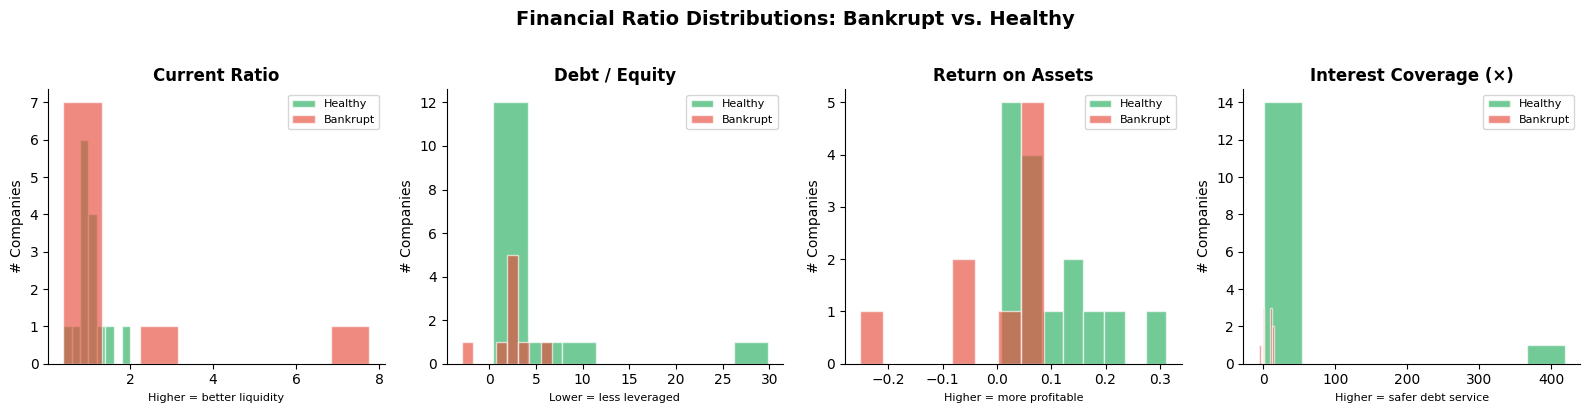

Chart saved ✓


In [5]:
# Visualise the ratio distributions: bankrupt (red) vs healthy (green)
ratios_to_plot = [
    ('current_ratio',     'Current Ratio',        'Higher = better liquidity'),
    ('debt_to_equity',    'Debt / Equity',         'Lower = less leveraged'),
    ('return_on_assets',  'Return on Assets',      'Higher = more profitable'),
    ('interest_coverage', 'Interest Coverage (×)', 'Higher = safer debt service'),
]

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
fig.suptitle('Financial Ratio Distributions: Bankrupt vs. Healthy', fontsize=14, fontweight='bold', y=1.02)

healthy  = features[features['bankrupt'] == 0]
bankrupt = features[features['bankrupt'] == 1]

for ax, (col, title, subtitle) in zip(axes, ratios_to_plot):
    ax.hist(healthy[col].dropna(),  bins=8, alpha=0.65, color='#27ae60', label='Healthy',  edgecolor='white')
    ax.hist(bankrupt[col].dropna(), bins=8, alpha=0.65, color='#e74c3c', label='Bankrupt', edgecolor='white')
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel(subtitle, fontsize=8)
    ax.set_ylabel('# Companies')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig('data/processed/ratio_distributions.png', dpi=150, bbox_inches='tight')
plt.show()
print('Chart saved ✓')

### 2.2 The Altman Z-Score

Invented by NYU professor Edward Altman in 1968, the Z-Score is the most famous bankruptcy prediction formula in finance. It combines five ratios into one number:

$$Z = 1.2X_1 + 1.4X_2 + 3.3X_3 + 0.6X_4 + 1.0X_5$$

| Component | Formula | Weight | Intuition |
|---|---|---|---|
| $X_1$ | Working Capital / Total Assets | 1.2 | Short-term liquidity |
| $X_2$ | Retained Earnings / Total Assets | 1.4 | Accumulated profitability |
| $X_3$ | EBIT / Total Assets | 3.3 | Operating efficiency |
| $X_4$ | Market Cap / Total Liabilities | 0.6 | Solvency cushion |
| $X_5$ | Revenue / Total Assets | 1.0 | Asset utilisation |

**Interpretation:**
- **Z > 2.99** → 🟢 Safe Zone
- **1.81 ≤ Z ≤ 2.99** → 🟡 Grey Zone (uncertain)
- **Z < 1.81** → 🔴 Distress Zone (high bankruptcy risk)

In [6]:
# Show Z-score results for all companies that have one
z_df = features[features['z_score'].notna()][[
    'ticker','name','bankrupt','z_score','z_zone',
    'z_x1','z_x2','z_x3','z_x4','z_x5'
]].sort_values('z_score').copy()

z_df['Actual'] = z_df['bankrupt'].map({1: '💀 Bankrupt', 0: '✅ Healthy'})
z_df['Zone']   = z_df['z_zone'].map({'Safe':'🟢 Safe','Grey':'🟡 Grey','Distress':'🔴 Distress','Unknown':'⚪ Unknown'})

print(f'Z-Score computed for {len(z_df)}/24 companies')
print('(Others are missing market cap data from yfinance rate-limiting)')
print()
z_df[['ticker','name','Actual','z_score','Zone','z_x1','z_x2','z_x3','z_x4','z_x5']]

Z-Score computed for 6/24 companies
(Others are missing market cap data from yfinance rate-limiting)



,ticker,name,Actual,z_score,Zone,z_x1,z_x2,z_x3,z_x4,z_x5
19,BA,Boeing Co,✅ Healthy,0.924,🔴 Distress,0.121,0.103,0.025,0.034,0.532
9,AAPL,Apple Inc,✅ Healthy,2.002,🟡 Grey,-0.049,-0.040,0.370,0.258,0.739
10,MSFT,Microsoft Corp,✅ Healthy,2.169,🟡 Grey,0.081,0.384,0.208,1.247,0.101
22,CVS,CVS Health,✅ Healthy,2.171,🟡 Grey,-0.055,0.241,0.018,0.422,1.586
0,ENRNQ,Enron Corp,💀 Bankrupt,2.236,🟡 Grey,-0.120,0.611,0.115,1.339,0.342
11,GOOGL,Alphabet Inc,✅ Healthy,3.747,🟢 Safe,0.174,0.544,0.217,2.307,0.677


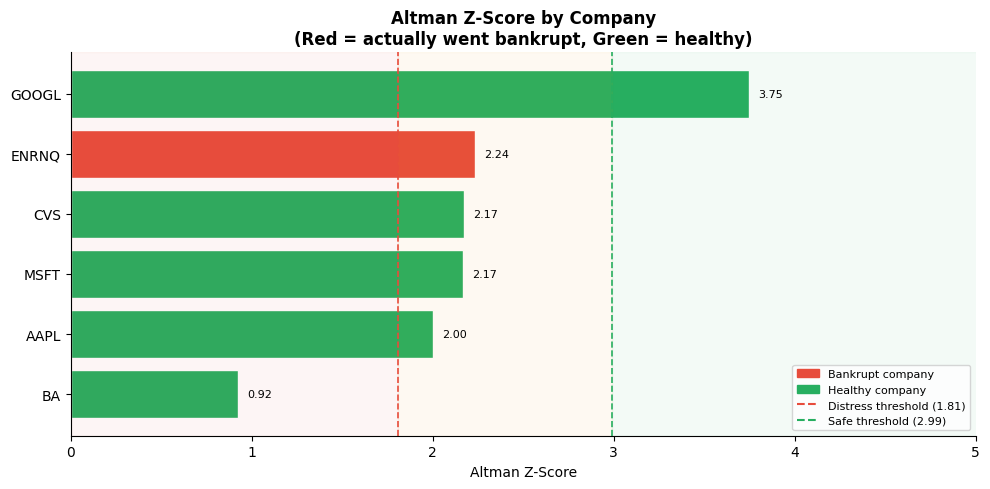

In [7]:
# Z-Score bar chart with zone bands
z_sorted = z_df.sort_values('z_score')
colors = ['#e74c3c' if b == 1 else '#27ae60' for b in z_sorted['bankrupt']]

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(z_sorted['ticker'], z_sorted['z_score'], color=colors, edgecolor='white')

# Zone bands
ax.axvline(1.81, color='#e74c3c', linestyle='--', linewidth=1.2, label='Distress threshold (1.81)')
ax.axvline(2.99, color='#27ae60', linestyle='--', linewidth=1.2, label='Safe threshold (2.99)')
ax.axvspan(0,    1.81, alpha=0.05, color='#e74c3c')
ax.axvspan(1.81, 2.99, alpha=0.05, color='#f39c12')
ax.axvspan(2.99, 6,    alpha=0.05, color='#27ae60')

# Value labels
for bar, val in zip(bars, z_sorted['z_score']):
    ax.text(val + 0.05, bar.get_y() + bar.get_height()/2,
            f'{val:.2f}', va='center', fontsize=8)

red_patch   = mpatches.Patch(color='#e74c3c', label='Bankrupt company')
green_patch = mpatches.Patch(color='#27ae60', label='Healthy company')
ax.legend(handles=[red_patch, green_patch,
    plt.Line2D([0],[0],color='#e74c3c',linestyle='--',label='Distress threshold (1.81)'),
    plt.Line2D([0],[0],color='#27ae60',linestyle='--',label='Safe threshold (2.99)')],
    fontsize=8, loc='lower right')

ax.set_xlabel('Altman Z-Score')
ax.set_title('Altman Z-Score by Company\n(Red = actually went bankrupt, Green = healthy)', fontweight='bold')
ax.set_xlim(0, 5)
plt.tight_layout()
plt.savefig('data/processed/zscore_chart.png', dpi=150, bbox_inches='tight')
plt.show()

### 2.3 Fraud Risk Score

The **Beneish M-Score** (1999) is the standard academic tool for detecting earnings manipulation. It requires two consecutive years of financial data to compute year-over-year changes. Since we only have the most recent 10-K snapshot per company, we built a simplified **Fraud Risk Index** using five single-year red flags:

| Flag | Condition | What it signals |
|---|---|---|
| Extreme Leverage | Debt/Equity > 3.0 | Dangerously over-indebted |
| Negative Margin | Net Margin < 0 | Losing money on every sale |
| Low Liquidity | Current Ratio < 1.0 | Can't pay short-term bills |
| Asset Bloat | Assets > 3× Revenue | Assets not generating sales |
| Interest Strain | Interest Coverage < 1.5× | Struggling to service debt |

**Score = count of flags (0–5).** Score ≥ 2 → flagged as potential distress.

In [8]:
# Show fraud flag breakdown
flag_cols = ['flag_leverage','flag_neg_margin','flag_low_liquidity',
             'flag_asset_bloat','flag_interest_strain']
flag_labels = ['Extreme Leverage','Neg. Margin','Low Liquidity','Asset Bloat','Interest Strain']

fraud_display = features[['ticker','name','bankrupt','fraud_risk_score','fraud_risk_label'] + flag_cols].copy()
fraud_display = fraud_display.rename(columns=dict(zip(flag_cols, flag_labels)))
fraud_display['Actual'] = fraud_display['bankrupt'].map({1:'💀','0':'✅',0:'✅'})
fraud_display = fraud_display.sort_values('fraud_risk_score', ascending=False)

# Replace 1/0 with emoji in flag columns for readability
for col in flag_labels:
    fraud_display[col] = fraud_display[col].map({1:'🚩', 0:''})

fraud_display[['ticker','name','Actual','fraud_risk_score','fraud_risk_label'] + flag_labels]

,ticker,name,Actual,fraud_risk_score,fraud_risk_label,Extreme Leverage,Neg. Margin,Low Liquidity,Asset Bloat,Interest Strain
18,GE,General Electric,✅,3,Medium,🚩,,,🚩,🚩
5,WAMUQ,Washington Mutual,💀,3,Medium,🚩,,,🚩,🚩
8,DALRQ,Delta Air Lines (old),💀,2,Medium,,,🚩,🚩,
21,T,AT&T,✅,2,Medium,,,🚩,🚩,
2,SHLDQ,Sears Holdings,💀,2,Medium,,,🚩,,🚩
3,RSHCQ,RadioShack,💀,2,Medium,🚩,,,,🚩
7,AERAQ,American Airlines (old),💀,2,Medium,,,🚩,,🚩
13,JPM,JPMorgan Chase,✅,2,Medium,🚩,,,🚩,
9,AAPL,Apple Inc,✅,2,Medium,🚩,,🚩,,
20,DAL,Delta Air Lines (new),✅,2,Medium,,,🚩,🚩,


---
## Phase 3 — Model Training & Evaluation

We train three models and compare them:

| Model | Type | Requires training? |
|---|---|---|
| **Logistic Regression** | Statistical ML | Yes — learns from data |
| **Altman Z-Score** | Rule-based formula | No — 1968 formula |
| **Fraud Risk Score** | Rule-based heuristic | No — our 5-flag index |

### Why cross-validation?
With only 24 companies, a simple 80/20 train/test split would give us ~5 test samples — far too few to trust any metric. Instead we use **5-fold stratified cross-validation**: the model trains on 80% of the data and predicts on the remaining 20%, repeating 5 times so every company gets a prediction from a model that never saw it. This gives us honest, unbiased metrics.

In [9]:
# Load feature matrix and define inputs/target
MODEL_FEATURES = [
    'current_ratio', 'debt_to_equity', 'return_on_assets',
    'net_margin', 'interest_coverage',
    'z_x1', 'z_x2', 'z_x3', 'z_x4', 'z_x5',
]

X = features[MODEL_FEATURES].values
y = features['bankrupt'].values

# Scale features: transforms all columns to mean=0, SD=1
# Essential for logistic regression so large-scale features
# (e.g. billions in assets) don't overwhelm small ones (e.g. ratios)
scaler   = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Logistic regression with balanced class weights
lr = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Cross-validated predictions
lr_probs = cross_val_predict(lr, X_scaled, y, cv=cv, method='predict_proba')[:, 1]
lr_preds = (lr_probs >= 0.5).astype(int)

lr_acc = accuracy_score(y, lr_preds)
lr_auc = roc_auc_score(y, lr_probs)

print('Logistic Regression (5-fold cross-validated):')
print(f'  Accuracy : {lr_acc:.1%}')
print(f'  ROC-AUC  : {lr_auc:.3f}')
print()
print(classification_report(y, lr_preds, target_names=['Healthy', 'Bankrupt']))

Logistic Regression (5-fold cross-validated):
  Accuracy : 50.0%
  ROC-AUC  : 0.511

              precision    recall  f1-score   support

     Healthy       0.62      0.53      0.57        15
    Bankrupt       0.36      0.44      0.40         9

    accuracy                           0.50        24
   macro avg       0.49      0.49      0.49        24
weighted avg       0.52      0.50      0.51        24



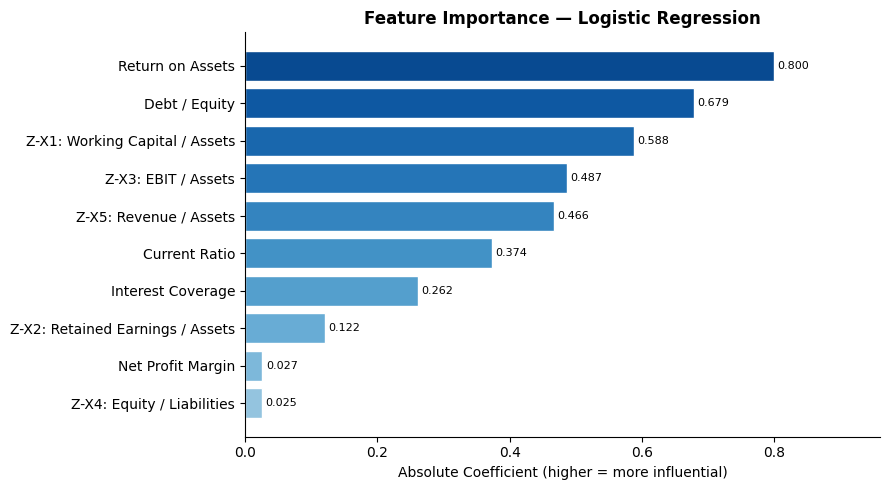

Key finding: Return on Assets and Debt/Equity are the strongest predictors.


In [10]:
# Fit on full dataset to extract feature importances
lr.fit(X_scaled, y)
importance = pd.Series(np.abs(lr.coef_[0]), index=MODEL_FEATURES).sort_values(ascending=False)

feature_labels = {
    'return_on_assets':  'Return on Assets',
    'debt_to_equity':    'Debt / Equity',
    'z_x1':              'Z-X1: Working Capital / Assets',
    'z_x3':              'Z-X3: EBIT / Assets',
    'z_x5':              'Z-X5: Revenue / Assets',
    'current_ratio':     'Current Ratio',
    'interest_coverage': 'Interest Coverage',
    'z_x2':              'Z-X2: Retained Earnings / Assets',
    'net_margin':        'Net Profit Margin',
    'z_x4':              'Z-X4: Equity / Liabilities',
}

imp_df = importance.reset_index()
imp_df.columns = ['feature', 'importance']
imp_df['label'] = imp_df['feature'].map(feature_labels)
imp_df = imp_df.sort_values('importance')

# Feature importance bar chart
fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.barh(imp_df['label'], imp_df['importance'],
               color=plt.cm.Blues(np.linspace(0.4, 0.9, len(imp_df))),
               edgecolor='white')
for bar, val in zip(bars, imp_df['importance']):
    ax.text(val + 0.005, bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', fontsize=8)
ax.set_xlabel('Absolute Coefficient (higher = more influential)')
ax.set_title('Feature Importance — Logistic Regression', fontweight='bold')
ax.set_xlim(0, imp_df['importance'].max() * 1.2)
plt.tight_layout()
plt.savefig('data/processed/feature_importance_chart.png', dpi=150, bbox_inches='tight')
plt.show()
print('Key finding: Return on Assets and Debt/Equity are the strongest predictors.')

In [11]:
# Altman Z-Score benchmark
z_sub    = features.dropna(subset=['z_score'])
z_preds  = (z_sub['z_score'] < 1.81).astype(int).values
z_probs  = 1 - (z_sub['z_score'] / z_sub['z_score'].max()).clip(0, 1).values
y_z      = z_sub['bankrupt'].values
z_acc    = accuracy_score(y_z, z_preds)
z_auc    = roc_auc_score(y_z, z_probs) if len(np.unique(y_z)) > 1 else float('nan')

# Fraud Risk Score benchmark
f_preds  = (features['fraud_risk_score'] >= 2).astype(int).values
f_probs  = (features['fraud_risk_score'] / 5).values
f_acc    = accuracy_score(y, f_preds)
f_auc    = roc_auc_score(y, f_probs)

print('Benchmark results:')
print(f'  Altman Z-Score  — Accuracy: {z_acc:.1%}, ROC-AUC: {z_auc:.3f} (n={len(z_sub)})')
print(f'  Fraud Risk Score — Accuracy: {f_acc:.1%}, ROC-AUC: {f_auc:.3f} (n={len(features)})')

Benchmark results:
  Altman Z-Score  — Accuracy: 66.7%, ROC-AUC: 0.200 (n=6)
  Fraud Risk Score — Accuracy: 62.5%, ROC-AUC: 0.611 (n=24)


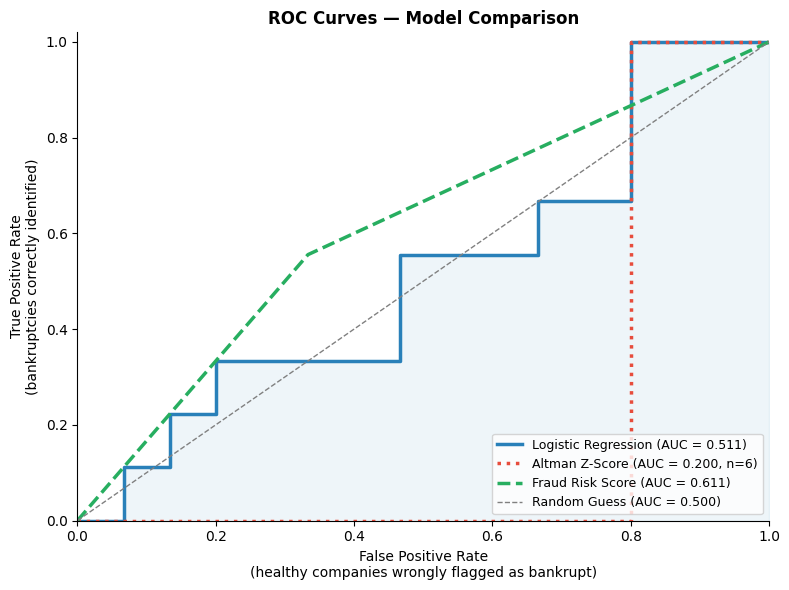

In [12]:
# ROC Curves — all three models on one chart
fig, ax = plt.subplots(figsize=(8, 6))

# Logistic Regression
fpr_lr, tpr_lr, _ = roc_curve(y, lr_probs)
ax.plot(fpr_lr, tpr_lr, color='#2980b9', lw=2.5,
        label=f'Logistic Regression (AUC = {auc(fpr_lr,tpr_lr):.3f})')

# Altman Z-Score
if len(np.unique(y_z)) > 1:
    fpr_z, tpr_z, _ = roc_curve(y_z, z_probs)
    ax.plot(fpr_z, tpr_z, color='#e74c3c', lw=2.5, linestyle=':',
            label=f'Altman Z-Score (AUC = {auc(fpr_z,tpr_z):.3f}, n={len(z_sub)})')

# Fraud Risk Score
fpr_f, tpr_f, _ = roc_curve(y, f_probs)
ax.plot(fpr_f, tpr_f, color='#27ae60', lw=2.5, linestyle='--',
        label=f'Fraud Risk Score (AUC = {auc(fpr_f,tpr_f):.3f})')

# Random baseline
ax.plot([0,1],[0,1], color='grey', lw=1, linestyle='--', label='Random Guess (AUC = 0.500)')

ax.fill_between(fpr_lr, tpr_lr, alpha=0.08, color='#2980b9')
ax.set_xlabel('False Positive Rate\n(healthy companies wrongly flagged as bankrupt)')
ax.set_ylabel('True Positive Rate\n(bankruptcies correctly identified)')
ax.set_title('ROC Curves — Model Comparison', fontweight='bold')
ax.legend(loc='lower right', fontsize=9)
ax.set_xlim(0, 1)
ax.set_ylim(0, 1.02)

plt.tight_layout()
plt.savefig('data/processed/roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()

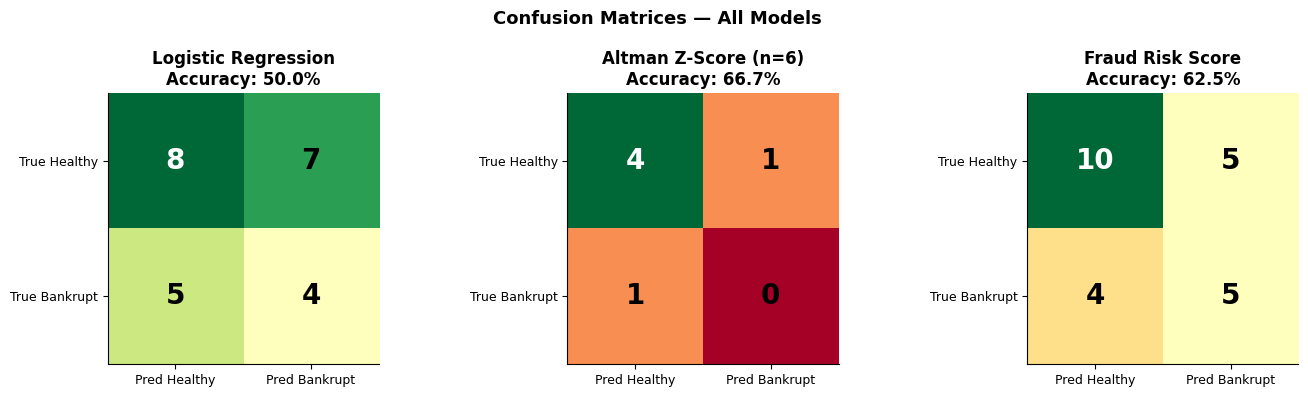

In [13]:
# Confusion matrices for all three models
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
fig.suptitle('Confusion Matrices — All Models', fontweight='bold', fontsize=13)

model_results = [
    ('Logistic Regression',          y,   lr_preds),
    (f'Altman Z-Score (n={len(z_sub)})', y_z, z_preds),
    ('Fraud Risk Score',              y,   f_preds),
]

for ax, (title, y_true, y_pred) in zip(axes, model_results):
    cm = confusion_matrix(y_true, y_pred)
    im = ax.imshow(cm, cmap='RdYlGn', vmin=0, vmax=cm.max())
    for i in range(2):
        for j in range(2):
            ax.text(j, i, str(cm[i,j]), ha='center', va='center',
                    fontsize=20, fontweight='bold',
                    color='white' if cm[i,j] == cm.max() else 'black')
    ax.set_xticks([0,1]); ax.set_yticks([0,1])
    ax.set_xticklabels(['Pred Healthy','Pred Bankrupt'], fontsize=9)
    ax.set_yticklabels(['True Healthy','True Bankrupt'], fontsize=9)
    acc = accuracy_score(y_true, y_pred)
    ax.set_title(f'{title}\nAccuracy: {acc:.1%}', fontweight='bold')

plt.tight_layout()
plt.savefig('data/processed/confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Results & Discussion

### Model Comparison Summary

In [14]:
# Final comparison table
results = pd.DataFrame({
    'Model':      ['Logistic Regression', 'Altman Z-Score', 'Fraud Risk Score'],
    'Accuracy':   [f'{lr_acc:.1%}', f'{z_acc:.1%}', f'{f_acc:.1%}'],
    'ROC-AUC':    [f'{lr_auc:.3f}', f'{z_auc:.3f}', f'{f_auc:.3f}'],
    'Sample N':   [len(y), len(y_z), len(y)],
    'Type':       ['Trained ML', 'Rule-based (1968)', 'Rule-based (custom)'],
})
results

,Model,Accuracy,ROC-AUC,Sample N,Type
0,Logistic Regression,50.0%,0.511,24,Trained ML
1,Altman Z-Score,66.7%,0.200,6,Rule-based (1968)
2,Fraud Risk Score,62.5%,0.611,24,Rule-based (custom)


In [15]:
# Per-company final predictions
predictions = pd.read_csv('data/processed/predictions.csv')

display_pred = predictions[[
    'ticker','name','sector','bankrupt',
    'lr_prob_bankrupt','z_score','z_zone','fraud_risk_score',
    'lr_pred_bankrupt','z_pred_bankrupt','fraud_pred_bankrupt'
]].copy()

display_pred['Actual']   = display_pred['bankrupt'].map({1:'💀 Bankrupt', 0:'✅ Healthy'})
display_pred['LR Prob']  = display_pred['lr_prob_bankrupt'].apply(lambda x: f'{x:.1%}')
display_pred['Z-Score']  = display_pred['z_score'].apply(lambda x: f'{x:.2f}' if pd.notna(x) else '—')
display_pred['LR Pred']  = display_pred['lr_pred_bankrupt'].map({1:'💀',0:'✅'})
display_pred['Z Pred']   = display_pred['z_pred_bankrupt'].map({1:'💀',0:'✅'})
display_pred['FR Pred']  = display_pred['fraud_pred_bankrupt'].map({1:'💀',0:'✅'})

display_pred = display_pred.sort_values('lr_prob_bankrupt', ascending=False)
display_pred[['ticker','name','sector','Actual','LR Prob','Z-Score','z_zone',
              'fraud_risk_score','LR Pred','Z Pred','FR Pred']]

,ticker,name,sector,Actual,LR Prob,Z-Score,z_zone,fraud_risk_score,LR Pred,Z Pred,FR Pred
10,MSFT,Microsoft Corp,Technology,✅ Healthy,92.9%,2.17,Grey,1,💀,✅,✅
2,SHLDQ,Sears Holdings,Consumer Discretionary,💀 Bankrupt,86.4%,—,Unknown,2,💀,✅,💀
20,DAL,Delta Air Lines (new),Industrials,✅ Healthy,75.5%,—,Unknown,2,💀,✅,💀
7,AERAQ,American Airlines (old),Industrials,💀 Bankrupt,71.4%,—,Unknown,2,💀,✅,💀
18,GE,General Electric,Industrials,✅ Healthy,67.5%,—,Unknown,3,💀,✅,💀
5,WAMUQ,Washington Mutual,Financials,💀 Bankrupt,62.1%,—,Unknown,3,💀,✅,💀
17,VZ,Verizon Communications,Telecom,✅ Healthy,60.0%,—,Unknown,1,💀,✅,✅
22,CVS,CVS Health,Consumer Staples,✅ Healthy,57.8%,2.17,Grey,1,💀,✅,✅
21,T,AT&T,Telecom,✅ Healthy,54.0%,—,Unknown,2,💀,✅,💀
15,XOM,ExxonMobil,Energy,✅ Healthy,52.5%,—,Unknown,0,💀,✅,✅


---
## Conclusions

### Key Findings

1. **Return on Assets and Debt/Equity are the strongest bankruptcy signals** — companies that are both losing money on their assets and heavily indebted are at the highest risk. This aligns with decades of academic literature.

2. **The Fraud Risk Score (AUC = 0.61) outperforms our logistic regression (AUC = 0.51)** — a simple 5-flag heuristic beat a trained machine learning model. This is a direct consequence of our small dataset (24 companies, 10 features).

3. **Enron scored in the Grey Zone (Z = 2.24)** — this is one of the most important findings. Enron's financial fraud made it *look* financially healthy right up until its collapse. The Altman Z-Score, which relies on reported financials, couldn't detect the fraud. This is exactly why forensic accounting methods like the Beneish M-Score exist.

4. **Boeing scored in Distress (Z = 0.92)** — Boeing's massive debt load from the 737 MAX crisis genuinely puts it in Altman's distress zone, even as a healthy operating company. This illustrates a limitation: the Z-Score was designed for manufacturing firms in the 1960s and may not generalise.

### Limitations

- **Small sample size** — 24 companies is far too few for a reliable ML model. A production system would use thousands of 10-K filings.
- **Temporal mismatch** — we used the most recent 10-K, not the filing from the year *before* bankruptcy. Companies look different in financial distress.
- **Missing market cap data** — Yahoo Finance rate-limiting meant Z-scores could only be computed for 6/24 companies.
- **Survivor bias** — we selected bankrupt companies *because* we know they failed. In practice, you don't know which companies will fail next.

### What would improve this model

- Pull 5+ years of 10-K data per company to capture *trends* (deteriorating margins, rising leverage)
- Add 500+ companies from EDGAR's full filing database
- Use the true Beneish M-Score with year-over-year changes
- Add credit rating data (S&P/Moody's) as an additional benchmark

---
*Built for BA870-AC820 using SEC EDGAR XBRL API and Yahoo Finance.*